# WSN Occupancy System — UML Diagram Generation

This notebook generates UML/activity diagrams for the **Privacy-Preserving Multi-Modal WSN** project (Team 5) using [PlantUML](https://plantuml.com).

The diagrams illustrate the system decision flowchart: sensor polling on the STM32, congestion index computation, TPSN timestamping, GEAR routing, and threshold-based alert logic at the base station.

> **Prerequisite:** PlantUML requires **Java (JDK 8+)** to be installed on your system. Download it from https://adoptium.net or your OS package manager before running this notebook.

In [1]:
!pip install plantuml Pillow

  Using cached plantuml-0.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached httplib2-0.31.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached plantuml-0.3.0-py3-none-any.whl (5.8 kB)
Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached httplib2-0.31.2-py3-none-any.whl (91 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/4 [pyparsing]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1/4 [Pillow]
   ---------- ----------------------------- 1

In [2]:
import os
from pathlib import Path
import plantuml
from IPython.display import Image, display

In [3]:
UML_SOURCE = """
@startuml
skinparam defaultFontName Arial
skinparam defaultFontSize 12
skinparam ArrowColor #555555
skinparam ActivityBorderColor #555555
skinparam ActivityBackgroundColor #F5F5F5
skinparam ActivityDiamondBackgroundColor #FFF8E1
skinparam ActivityDiamondBorderColor #BA7517
skinparam NoteBackgroundColor #EDE9FE
skinparam NoteBorderColor #7F77DD

title WSN Occupancy System — Decision Flowchart

start

:TPSN time synchronization\n<size:10>BS = root; all motes sync via two-way exchange</size>;
note right: **TPSN layer**

repeat

  :STM32 polls all sensors\n<size:10>mm-wave radar, vibration, acoustic</size>;

  :Compute congestion index CI\n<size:10>CI = α·R + β·V + γ·A  (on STM32)</size>;

  :Send CI over UART\n<size:10>STM32 → sensing TelosB mote</size>;

  :Append TPSN timestamp\n<size:10>Sensing mote tags packet before TX</size>;
  note right: **TPSN layer**

  :GEAR: evaluate neighbors\n<size:10>Compute cost to BS for each neighbor</size>;
  note right: **GEAR layer**

  if (Closer neighbor to BS exists?) then (yes)
    :Forward packet to next hop;
  else (no)
    :Perimeter routing\n<size:10>Route around void region</size>;
    :Resume greedy forwarding\n<size:10>Once past void</size>;
  endif

  :Base station receives packet\n<size:10>Log CI + timestamp; update LCD</size>;

  if (CI above threshold?) then (yes)
    :Trigger congestion alert\n<size:10>Relay / LED output</size>;
  else (no)
  endif

repeat while (wait for next sample interval)

stop
@enduml
"""

Diagram saved to: D:\Source_Codes\01_Ongoing\07_DNES_Project\notebooks\wsn_flowchart.png


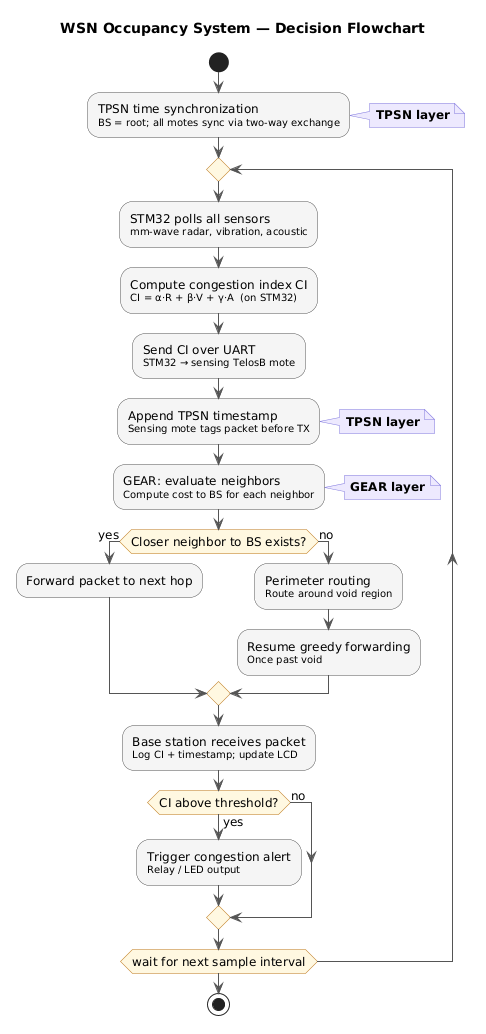

In [4]:
# Render the diagram via the PlantUML public server and save as PNG
output_path = Path("wsn_flowchart.png")

pl = plantuml.PlantUML(url="http://www.plantuml.com/plantuml/img/")
png_data = pl.processes(UML_SOURCE)

output_path.write_bytes(png_data)
print(f"Diagram saved to: {output_path.resolve()}")

display(Image(filename=str(output_path)))